<a href="https://colab.research.google.com/github/farahwadya/anomlies-setection-using-python/blob/main/Copy_of_Anomaly_Detection_(Core)credit_card_fraud_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import set_config
set_config(transform_output='pandas')

Task
In this assignment, you will use anomaly detection techniques to detect credit card fraud using this modified dataset originally from Kaggle. Each row represents one credit card transaction. This dataset has anonymized features, except for the amount of the transaction.

Your stakeholder reports that they have found that about 0.4% of transactions are fraudulent, and 99.6% are valid.  

Your task will be to locate anomalous transactions in this data using KMeans and IsolationForest models  

KMeans:

Remember to scale your data.
Fit a KMeans model to create 3 clusters.  Please use a random state of 42 for your model.
Use scipy.spatial.distance.cdist to create a matrix of distances between each data point and each cluster center
Define a list of the indices of the anomalous data using the threshold given by the stakeholder (99.6% valid).
Note that you cannot visualize your clusters since this dataset has 29 features. (To visualize, you could apply PCA to reduce the dimensionality to 2 features, but visualization is not required.)
Submit the notebook below.



# dataset

In [ ]:
fpath='/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week18/credit_card.csv'
df=pd.read_csv(fpath)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      10000 non-null  float64
 1   V2      10000 non-null  float64
 2   V3      10000 non-null  float64
 3   V4      10000 non-null  float64
 4   V5      10000 non-null  float64
 5   V6      10000 non-null  float64
 6   V7      10000 non-null  float64
 7   V8      10000 non-null  float64
 8   V9      10000 non-null  float64
 9   V10     10000 non-null  float64
 10  V11     10000 non-null  float64
 11  V12     10000 non-null  float64
 12  V13     10000 non-null  float64
 13  V14     10000 non-null  float64
 14  V15     10000 non-null  float64
 15  V16     10000 non-null  float64
 16  V17     10000 non-null  float64
 17  V18     10000 non-null  float64
 18  V19     10000 non-null  float64
 19  V20     10000 non-null  float64
 20  V21     10000 non-null  float64
 21  V22     10000 non-null  float64
 22 

In [ ]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.254287,0.283266,0.919481,0.290123,-0.060268,0.119328,-0.068060,-0.065865,0.812108,-0.223647,...,0.030729,-0.057396,-0.158022,-0.030401,0.017295,0.085811,0.107121,0.006845,0.003067,64.520252
std,1.522637,1.314546,1.163288,1.427511,1.173778,1.299279,1.078250,1.255474,1.166215,1.099040,...,0.595192,0.907699,0.631906,0.489834,0.591947,0.430758,0.556106,0.404949,0.267988,185.221202
min,-27.670569,-34.607649,-15.496222,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-6.329801,-13.193415,...,-13.276034,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.509250,0.000000
25%,-1.027537,-0.214263,0.424669,-0.589896,-0.645458,-0.633723,-0.535728,-0.192522,0.072521,-0.688422,...,-0.149775,-0.271001,-0.555175,-0.172704,-0.329963,-0.162928,-0.325964,-0.083980,-0.015625,5.380000
50%,-0.383856,0.292181,0.954225,0.235755,-0.156229,-0.160367,-0.052060,0.011440,0.815950,-0.340435,...,-0.020913,-0.128229,-0.145288,-0.044523,0.078389,0.118709,0.040788,-0.004320,0.016480,15.950000
75%,1.146465,0.913810,1.611713,1.138298,0.359786,0.489572,0.472143,0.264272,1.517105,0.170406,...,0.160834,0.031776,0.238299,0.084179,0.407717,0.360469,0.467256,0.118735,0.078644,53.175000
max,1.960497,8.636214,4.101716,10.463020,34.099309,21.393069,34.303177,5.060381,10.392889,12.259949,...,8.012574,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000


# data cleaning
data have no nulls so we only need to scale it

In [ ]:
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df)
df_scaled

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.726092,-0.270865,1.389980,0.762227,-0.236899,0.264052,0.285346,0.131083,-0.384443,0.286120,...,0.370795,0.043066,0.689788,-0.163478,0.083851,0.099198,-0.532722,0.312929,-0.090009,0.459472
1,0.949810,-0.013020,-0.647336,0.110710,0.102482,-0.155239,-0.009963,0.120253,-0.915428,0.051569,...,-0.167706,-0.185510,-0.760673,0.268858,-0.603364,0.188884,0.033761,-0.039088,0.043500,-0.333835
2,-0.725138,-1.235035,0.733929,0.062810,-0.377373,1.293991,0.797185,0.249752,-1.995239,0.392444,...,0.830447,0.336466,1.471338,1.918734,-1.193707,-0.959876,-0.442774,-0.153601,-0.234422,1.696110
3,-0.467623,-0.356408,0.750937,-0.808030,0.042565,0.868121,0.283501,0.353112,-1.885794,0.153501,...,-0.401179,-0.056083,0.258431,-0.326493,-2.015264,1.303733,-0.591732,0.137995,0.217896,0.318445
4,-0.593701,0.452248,0.540940,0.079101,-0.295578,-0.018016,0.613062,-0.163028,0.004829,0.888749,...,0.634808,0.052846,1.513434,-0.218569,0.209441,-0.677493,0.710640,0.524976,0.791442,0.029532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.582254,0.822928,0.675781,-0.436159,0.339986,-0.211684,0.974073,-0.390541,0.960755,1.355617,...,0.814716,-0.270513,0.367525,-0.088748,0.237025,-1.341345,0.139345,-0.321884,-1.174255,-0.294421
9996,-0.698262,0.165437,1.081422,-0.358389,0.680357,-1.081387,0.501505,-0.183794,0.417743,-0.314791,...,-0.233550,-0.472572,-1.408476,-0.474189,0.435388,0.174699,-0.266039,-0.080968,-0.507701,-0.309647
9997,-1.414777,-0.618350,1.992252,-1.944731,-0.344833,-0.355713,-0.631952,0.059212,3.483615,-0.631703,...,-0.307809,-0.341595,1.258769,-1.745143,0.963114,1.413275,-0.319949,0.927441,-0.675591,-0.191782
9998,0.243406,-0.143847,-0.412310,0.410330,1.823885,3.221485,-0.476516,0.691276,0.544611,0.187903,...,0.599442,0.191866,1.413804,0.400581,1.603386,-2.899046,-0.703646,0.333142,0.155375,-0.019007


In [ ]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)


# kmeans model

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
# Saving the cluster centers as a dataframe for visibility
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns)
cluster_centers

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.562876,-0.373036,-0.773280,-0.122793,0.272775,0.710236,-0.233521,0.183856,-0.500804,0.152399,...,0.073084,-0.006122,-0.322439,-0.048543,0.485587,0.626963,-0.157132,0.003467,0.097661,0.163573
1,0.038553,-0.007515,0.193674,0.152989,-0.132329,-0.146710,-0.067318,-0.038558,0.457160,-0.098859,...,-0.070230,-0.042680,-0.009312,0.024708,-0.125136,-0.050194,0.166518,-0.065624,-0.011095,-0.017556
2,-0.568482,0.333627,0.191246,-0.261908,0.085593,-0.250195,0.358566,-0.063380,-0.669343,0.107425,...,0.106084,0.107232,0.295110,-0.018003,-0.111685,-0.410508,-0.265200,0.153980,-0.056110,-0.096435


In [ ]:
df['clusters']=kmeans.predict(df_scaled)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,clusters
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,2
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,2
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,2
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,2


In [ ]:
from scipy.spatial.distance import cdist

# distances shape = (#rows, #clusters)
distances = cdist(df_scaled, cluster_centers, metric='euclidean')

# save it in a dataframe
distance_df = pd.DataFrame(distances, columns=[f'Distance_to_Cluster_{i}' for i in range(kmeans.n_clusters)])
distance_df

,Distance_to_Cluster_0,Distance_to_Cluster_1,Distance_to_Cluster_2
0,3.763619,4.396796,2.723235
1,2.481479,3.683257,2.964150
2,7.169645,7.345224,6.467058
3,5.150452,5.675420,4.840838
4,4.230496,4.483864,3.044223
...,...,...,...
9995,5.114715,3.613210,4.312938
9996,4.365534,3.221438,4.157303
9997,7.473674,6.410456,7.181432
9998,6.210111,6.262758,6.668792


In [ ]:
# Get the minimum distance to any cluster for each point
min_distances = np.min(distances, axis=1)
# Display first 5 values
min_distances[:5]

array([2.72323458, 2.48147889, 6.46705846, 4.84083756, 3.04422311])

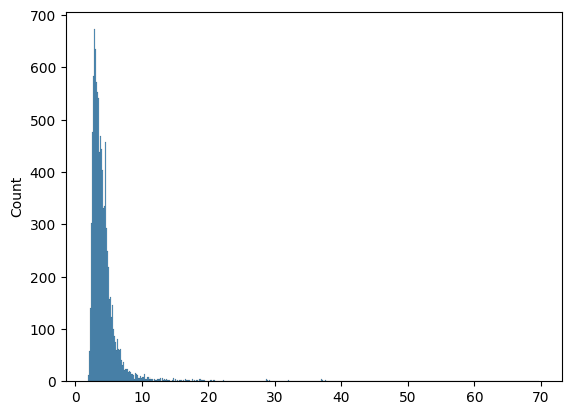

In [ ]:
# distance from closet centroid
ax = sns.histplot(min_distances)


Decide on a Threshold to Identify Anomalies


In [ ]:
# Set a threshold based on a percentile
threshold = np.percentile(min_distances, 99.6)
threshold

np.float64(20.818227126240366)

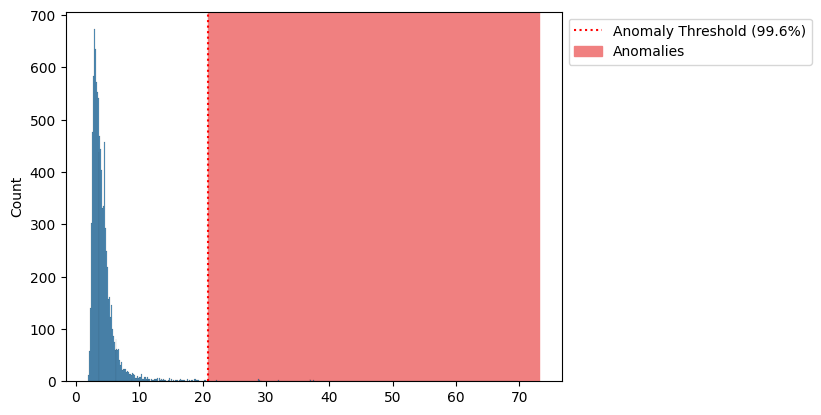

In [ ]:
# Visualize the distribution of distances and the anomaly threshold.
ax = sns.histplot(min_distances)
ax.axvline(threshold, color='red', ls=':', label='Anomaly Threshold (99.6%)')
ax.axvspan(threshold, ax.get_xlim()[1], color='lightcoral',zorder=0, label='Anomalies')
ax.legend(bbox_to_anchor=[1,1]);

In [ ]:
# Identify anomalies where the distance to closest cluster center is above the threshold
filter_anomalies = min_distances > threshold
# how many were found?
filter_anomalies.sum() # 40 anomalies

np.int64(40)

In [ ]:
# Getting the row indices of the anomalies
idx_anomalies = df_scaled[filter_anomalies].index
idx_anomalies

Index([ 159, 1376, 1619, 2156, 2212, 2439, 2594, 2654, 2756, 2911, 2914, 2917,
       2923, 3443, 5303, 5412, 5413, 5529, 5674, 5704, 5764, 5977, 6489, 6643,
       6672, 7322, 7338, 7470, 7596, 7597, 8124, 8163, 8437, 8442, 8856, 8939,
       8999, 9071, 9304, 9326],
      dtype='int64')

In [ ]:
# Slicing the anomalies from X (for demonstration)
df_scaled.iloc[idx_anomalies]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
159,-3.834960,-9.431468,-5.686284,2.104654,-1.153193,3.584223,4.522820,-0.129306,-1.147362,-1.366035,...,12.960326,2.518824,-3.332963,-7.192555,2.023902,-1.141962,-1.367622,-1.773317,2.499616,20.320071
1376,-2.418627,-3.007869,-2.040269,1.407855,-8.255103,4.877629,10.065097,-1.668099,-0.900585,-0.710429,...,-3.754280,-1.015485,1.764920,5.047600,0.394163,0.499370,1.889565,3.994384,-6.126389,12.890690
1619,-7.150070,-7.528445,-11.441444,4.009433,-27.290908,16.374319,31.878466,-5.938228,-2.347745,-2.195640,...,-19.791952,-5.125945,2.412080,-5.911458,1.395896,1.533320,1.248504,9.496001,15.504724,41.292747
2156,-3.674689,-9.158175,-3.656015,2.370064,-3.748184,0.415459,4.262012,-0.732546,-0.492485,-1.483717,...,12.238043,2.443958,-2.902722,-6.553469,1.000686,-2.487275,-0.031340,-1.778584,2.425582,19.461379
2212,-3.215208,3.026652,-1.687193,-2.215652,-0.775564,1.476574,-4.085387,-11.810305,0.773002,0.285954,...,-5.487786,16.278911,-6.764131,4.300451,-0.071619,-0.100710,-0.275131,1.512629,1.061451,-0.326762
2439,-7.824911,-12.184466,-1.114101,2.453688,9.132442,-5.838093,-6.342982,1.306016,-0.646520,-0.180378,...,7.457408,1.892358,-1.190891,0.083439,-0.193509,-0.965160,0.213631,0.481461,-8.850109,0.299547
2594,-1.524177,-2.246208,-3.438370,1.228373,-9.675750,5.977763,11.396173,-1.403798,-1.962029,-1.585241,...,1.340186,-0.064103,0.668031,4.593911,-1.331986,0.138431,-0.625159,2.898280,-2.338725,15.363209
2654,-4.789278,2.105598,-1.241513,0.500971,0.085842,2.026108,-5.749739,-15.222733,0.203976,0.678419,...,-6.412602,10.683389,-4.582514,5.469079,0.696040,0.498896,-0.683721,3.195176,-2.405010,-0.186922
2756,-6.913533,-7.777855,0.673923,1.964941,6.806898,-3.195860,-8.233600,-4.009462,1.273875,-0.009641,...,-8.166138,-4.784251,2.834458,-1.390803,1.062015,-1.474357,1.074814,8.311982,-4.891511,0.110575
2911,-2.686228,3.031804,-2.148883,-0.012320,-1.157837,1.912165,-10.291944,-18.772044,-2.282244,-4.544346,...,9.779945,-12.357685,6.045469,-0.347143,1.526074,1.239905,-0.878097,-0.345087,2.003279,-0.342960
